In [23]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from plots import *
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import itertools

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
data = load_data()

In [26]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff_1,...,lagged_tdiff_12,lagged_prec_12,lagged_tmed_12,lagged_tmax_12,lagged_tmin_12,lagged_tdiff_24,lagged_prec_24,lagged_tmed_24,lagged_tmax_24,lagged_tmin_24
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,1994-01-01,13.08,4.59,8.84,1,1994,145.2,8.49,2.138889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,1994-02-01,13.51,4.71,9.11,2,1994,130.6,8.80,2.174752,8.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,1994-03-01,19.63,8.29,13.96,3,1994,11.1,11.34,2.428336,8.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,1994-04-01,18.54,7.25,12.89,4,1994,43.2,11.29,2.423917,11.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-05-01,1994-05-01,20.15,10.77,15.46,5,1994,160.2,9.38,2.238580,11.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
target = 't_seasdiff'
exog=['lagged_tmed_24', 'lagged_prec_24', 'lagged_tmin_24', 'lagged_tmax_24']

In [28]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff_1,...,lagged_tdiff_12,lagged_prec_12,lagged_tmed_12,lagged_tmax_12,lagged_tmin_12,lagged_tdiff_24,lagged_prec_24,lagged_tmed_24,lagged_tmax_24,lagged_tmin_24
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,1994-01-01,13.08,4.59,8.84,1,1994,145.2,8.49,2.138889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,1994-02-01,13.51,4.71,9.11,2,1994,130.6,8.80,2.174752,8.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,1994-03-01,19.63,8.29,13.96,3,1994,11.1,11.34,2.428336,8.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,1994-04-01,18.54,7.25,12.89,4,1994,43.2,11.29,2.423917,11.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-05-01,1994-05-01,20.15,10.77,15.46,5,1994,160.2,9.38,2.238580,11.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
if target == 't_seasdiff':
    data["t_seasdiff"]= data["tdiff"].diff(24)
    data = data.dropna(subset=["t_seasdiff"])

# SARIMA / SARIMAX

In [30]:
len(data)

301

In [31]:
p, d, q = 0, 1, 1
P, D, Q, s = 1, 0, 0, 12


In [32]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

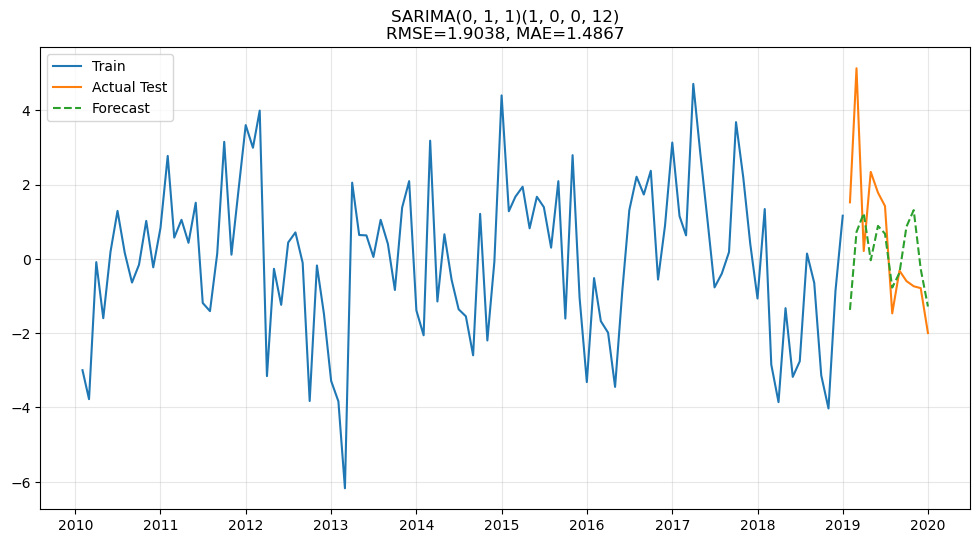

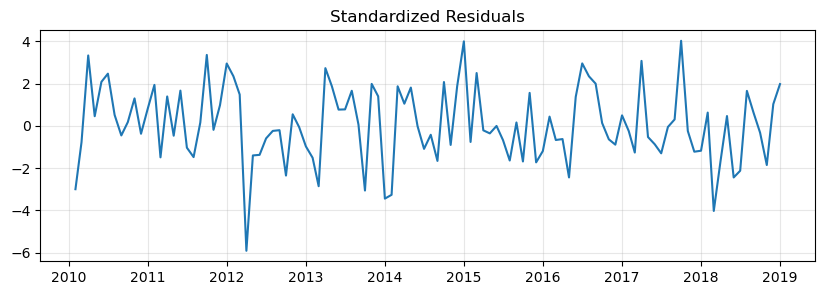

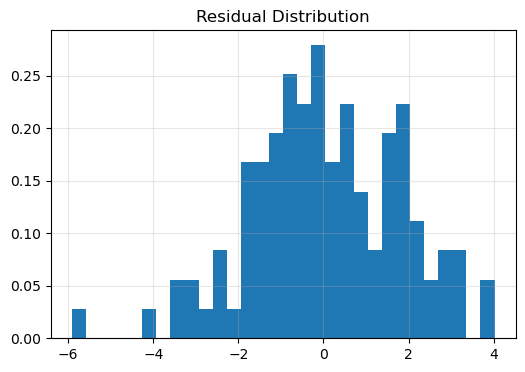

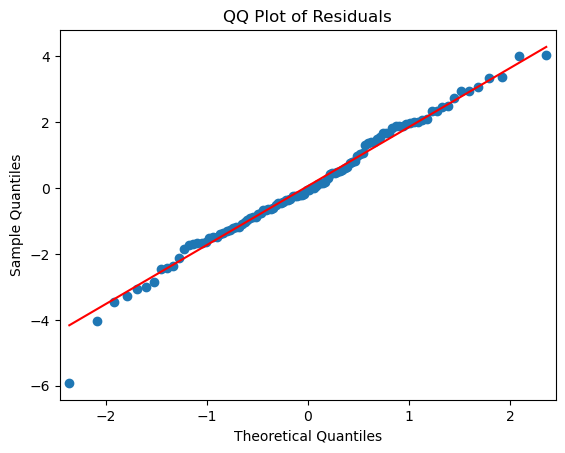

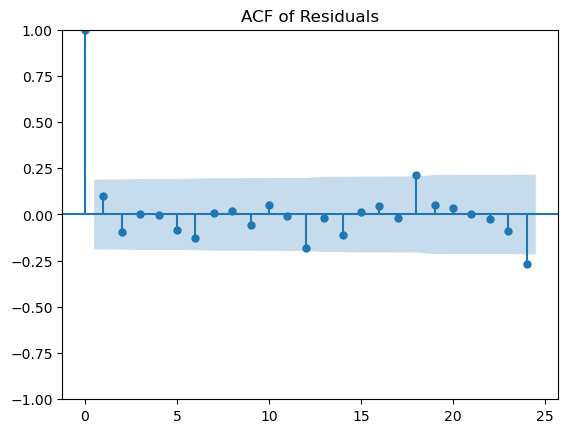

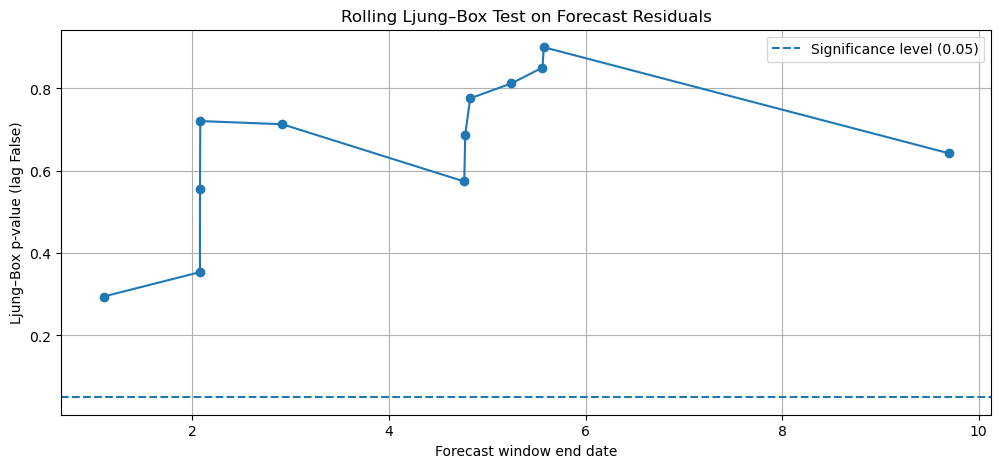

In [33]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [34]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s, exog= exog)

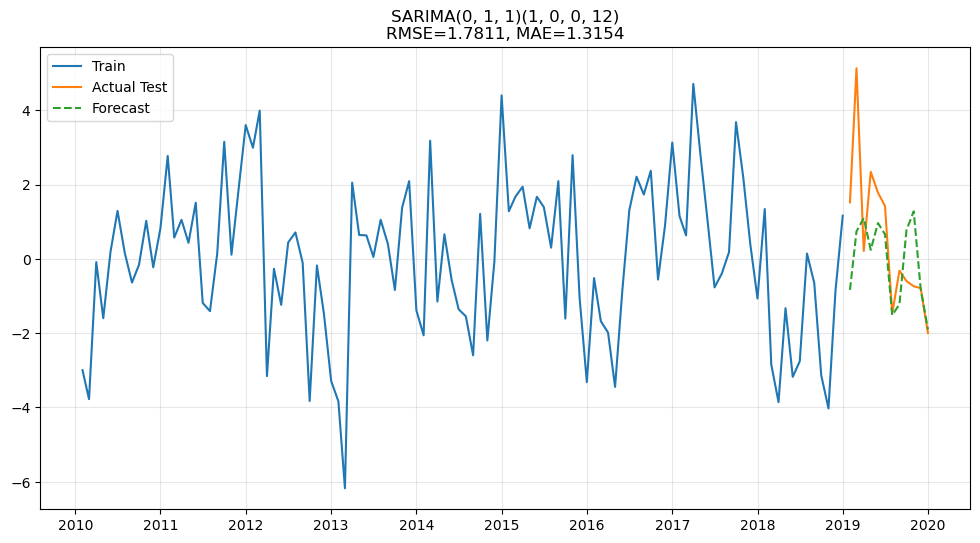

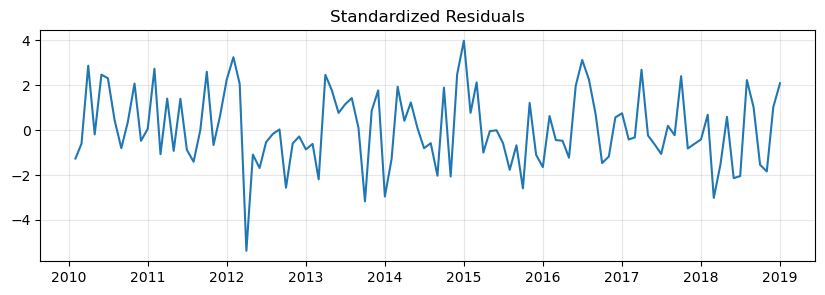

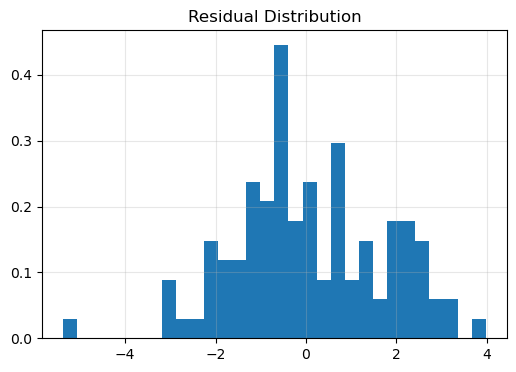

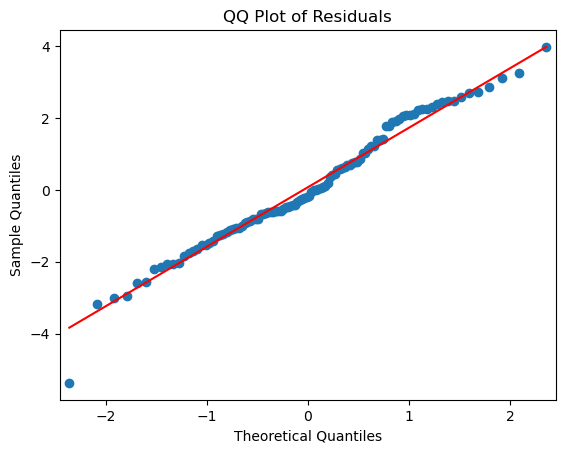

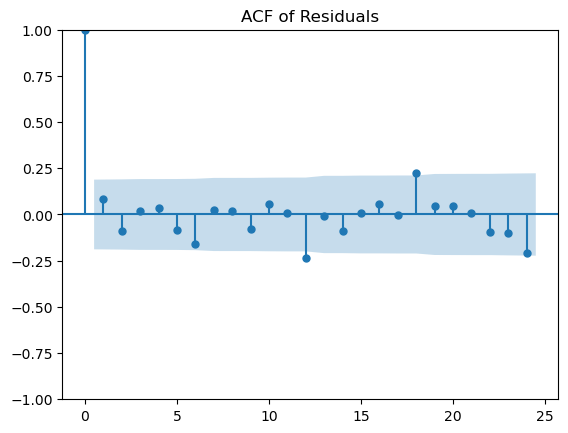

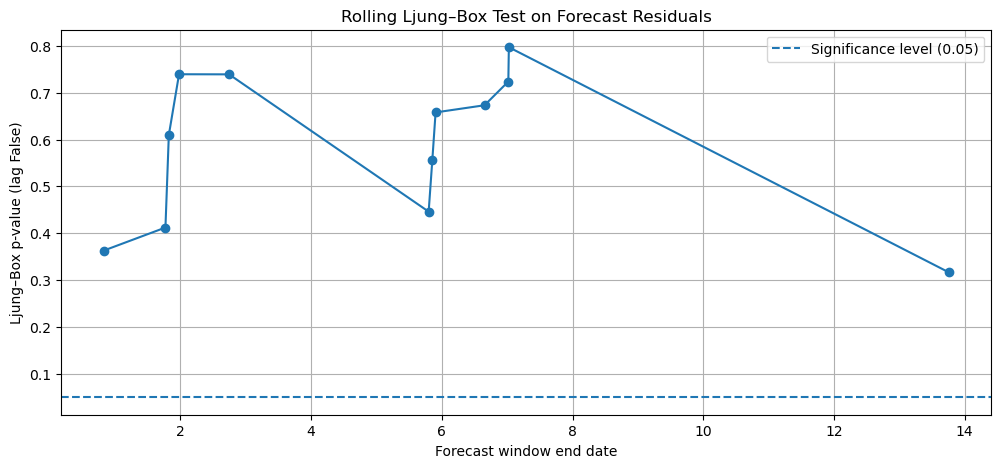

In [35]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [36]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(data[target], m=12, max_p=3, max_q=2, max_P=3, max_Q=3, d=0, D=0 ,max_lag=50)

candidates = cand_res["candidates"]
for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

n: 301
NaNs: 0
var: 3.7850357413273583
01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,1,12)
03. SARIMA(0,0,0)(1,0,0,12)
04. SARIMA(0,0,0)(1,0,1,12)
05. SARIMA(0,0,0)(2,0,0,12)
06. SARIMA(0,0,0)(2,0,1,12)
07. SARIMA(0,0,0)(3,0,0,12)
08. SARIMA(0,0,0)(3,0,1,12)
09. SARIMA(0,0,1)(0,0,0,12)
10. SARIMA(0,0,1)(0,0,1,12)
11. SARIMA(0,0,1)(1,0,0,12)
12. SARIMA(0,0,1)(1,0,1,12)
13. SARIMA(0,0,1)(2,0,0,12)
14. SARIMA(0,0,1)(2,0,1,12)
15. SARIMA(0,0,1)(3,0,0,12)
16. SARIMA(0,0,1)(3,0,1,12)
17. SARIMA(0,0,2)(0,0,0,12)
18. SARIMA(0,0,2)(0,0,1,12)
19. SARIMA(0,0,2)(1,0,0,12)
20. SARIMA(0,0,2)(1,0,1,12)
21. SARIMA(0,0,2)(2,0,0,12)
22. SARIMA(0,0,2)(2,0,1,12)
23. SARIMA(0,0,2)(3,0,0,12)
24. SARIMA(0,0,2)(3,0,1,12)
25. SARIMA(1,0,0)(0,0,0,12)
26. SARIMA(1,0,0)(0,0,1,12)
27. SARIMA(1,0,0)(1,0,0,12)
28. SARIMA(1,0,0)(1,0,1,12)
29. SARIMA(1,0,0)(2,0,0,12)
30. SARIMA(1,0,0)(2,0,1,12)
31. SARIMA(1,0,0)(3,0,0,12)
32. SARIMA(1,0,0)(3,0,1,12)
33. SARIMA(1,0,1)(0,0,0,12)
34. SARIMA(1,0,1)(0,0,1,12)
35. SARIM

In [37]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4612, MAE=1.0262
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.8736, MAE=1.5820
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.3172, MAE=0.9288
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8589, MAE=1.6117
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.3071, MAE=0.9122
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7056, MAE=1.4399
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.3532, MAE=0.9606
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9255, MAE=1.4754
Tried SARIMA(0,0,2)(0,0,1,12) -

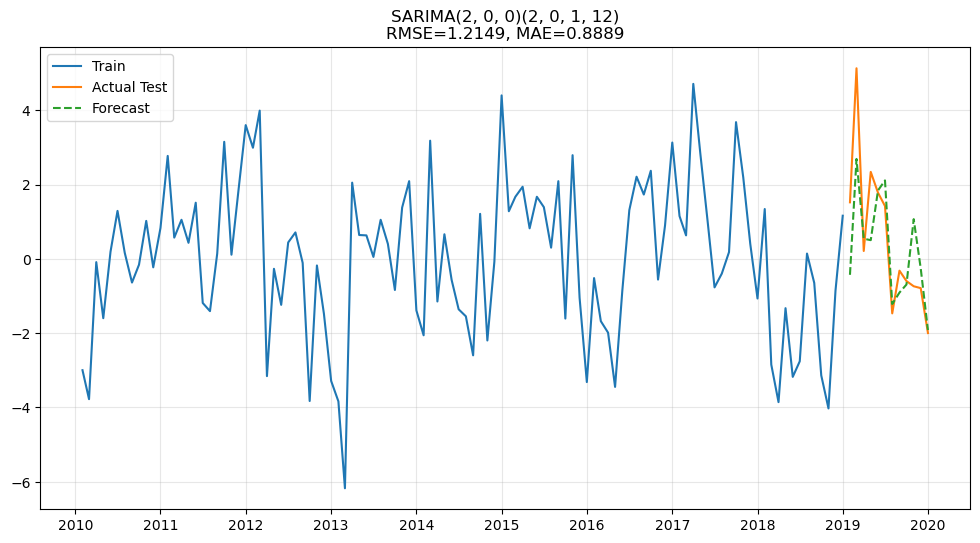

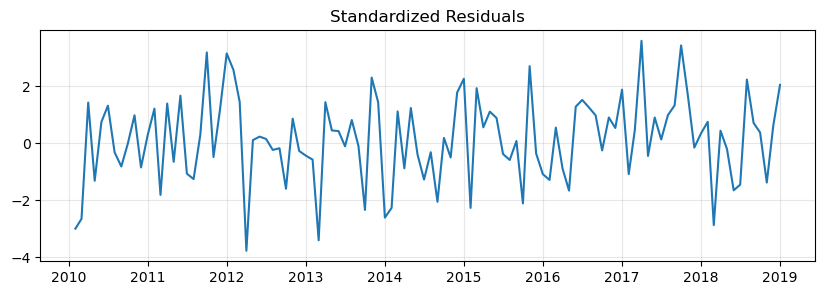

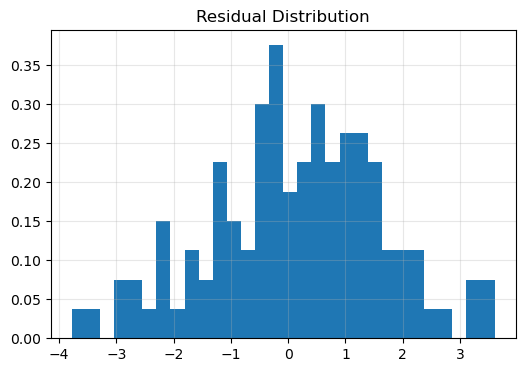

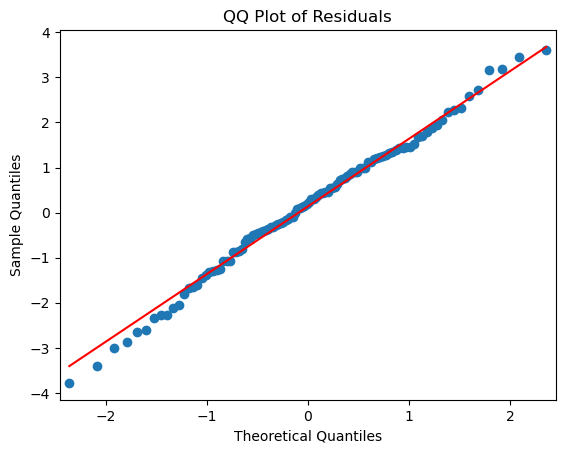

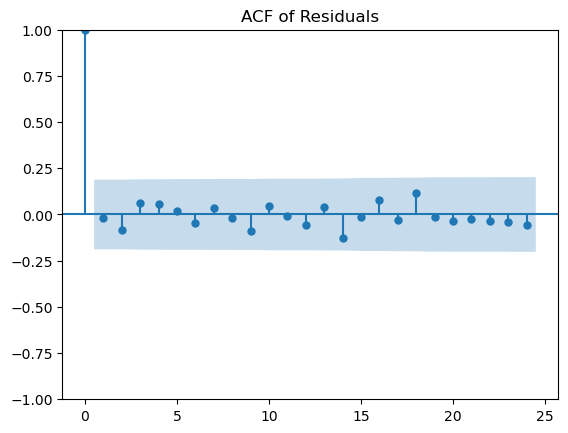

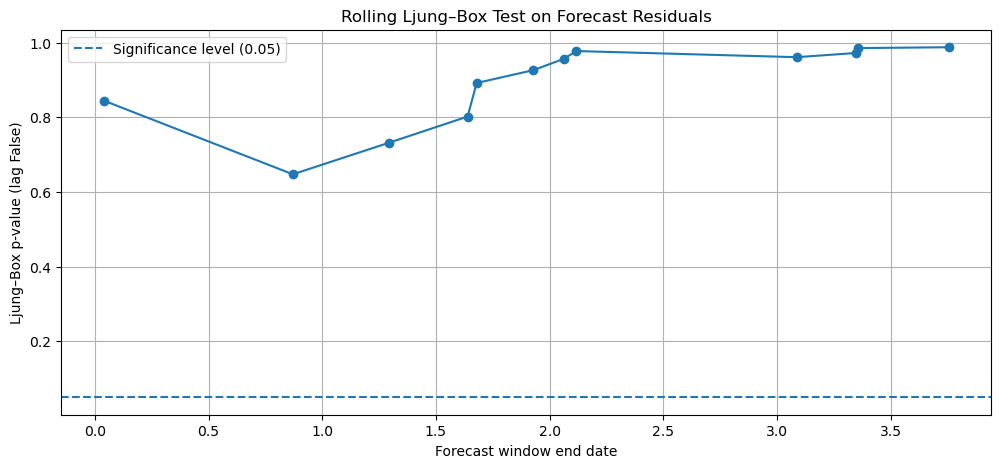

In [38]:
plot_sarimax_results(
    train=train,
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [39]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=exog,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=2.1128, MAE=1.6069
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.6106, MAE=1.2948
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.6922, MAE=1.3667
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.6578, MAE=1.3471
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.7884, MAE=1.5156
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.6920, MAE=1.4112
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7009, MAE=1.4140
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.7006, MAE=1.4134
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=2.0994, MAE=1.5743
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.5936, MAE=1.2671
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.6652, MAE=1.3100
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.6350, MAE=1.3113
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.7359, MAE=1.4334
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.6797, MAE=1.3782
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.6808, MAE=1.3702
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.6870, MAE=1.3784
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=2.0927, MAE=1.5684
Tried SARIMA(0,0,2)(0,0,1,12) -

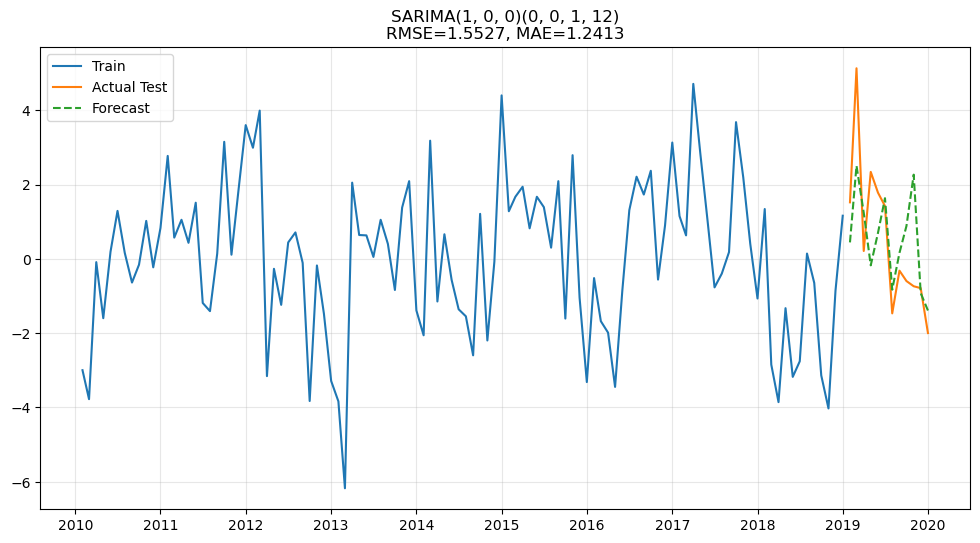

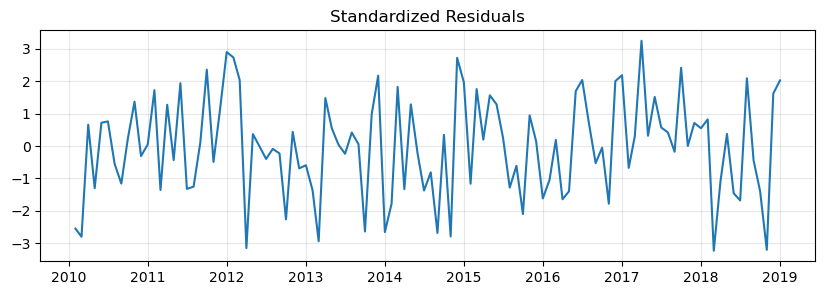

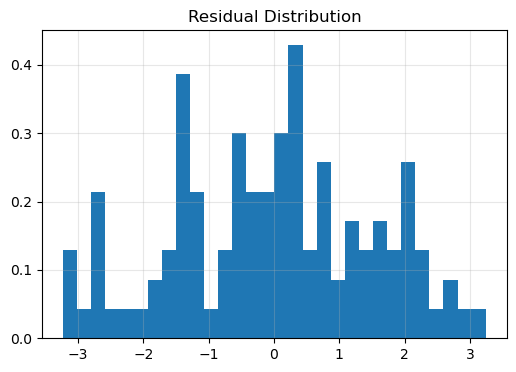

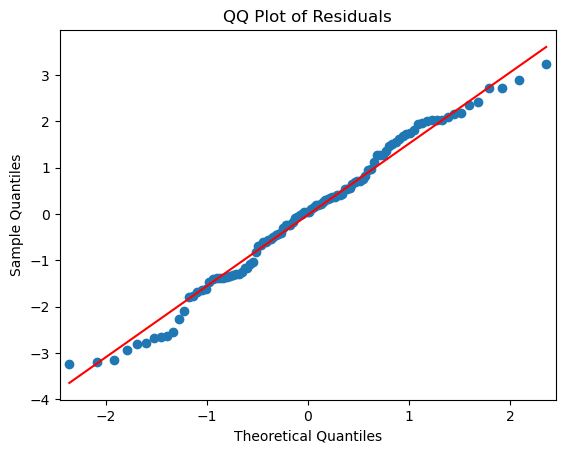

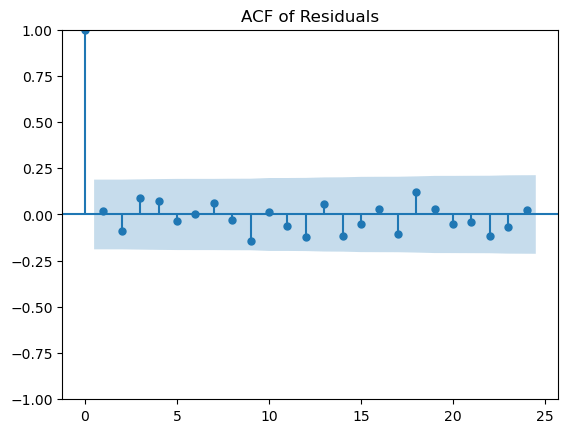

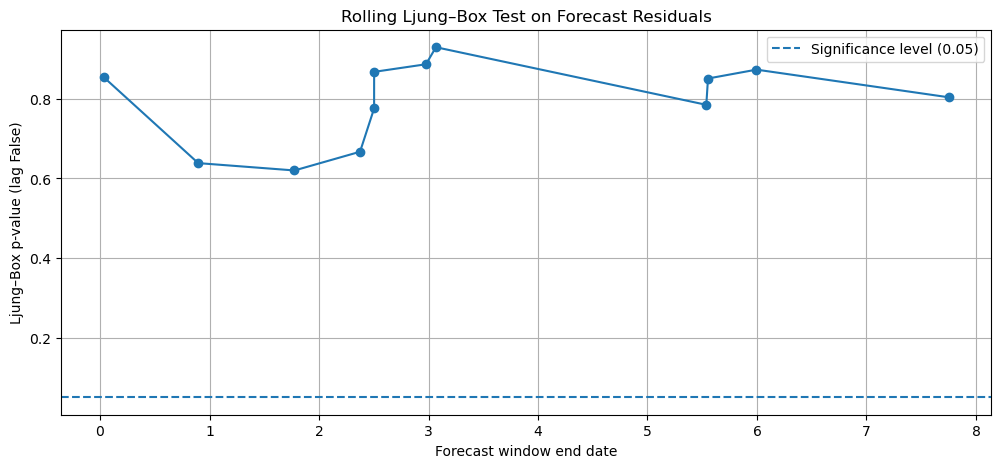

In [40]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

## Using AutoSarima with the current train/test split

In [41]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12)

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.00 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,3)[12] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(0,0,0)(0,0,4)[12] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,0,0)(0,0,5)[12] intercept   : AIC=420.388, Time=0.77 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=441.004, Time=0.02 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,0,0)(1,0,3)[12] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(0,0,0)(1,0,4)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.05 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(0,0,0)(2,0,3)[12] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,0,0)(3,0,0)[12] intercept   : AIC=425.607, Ti

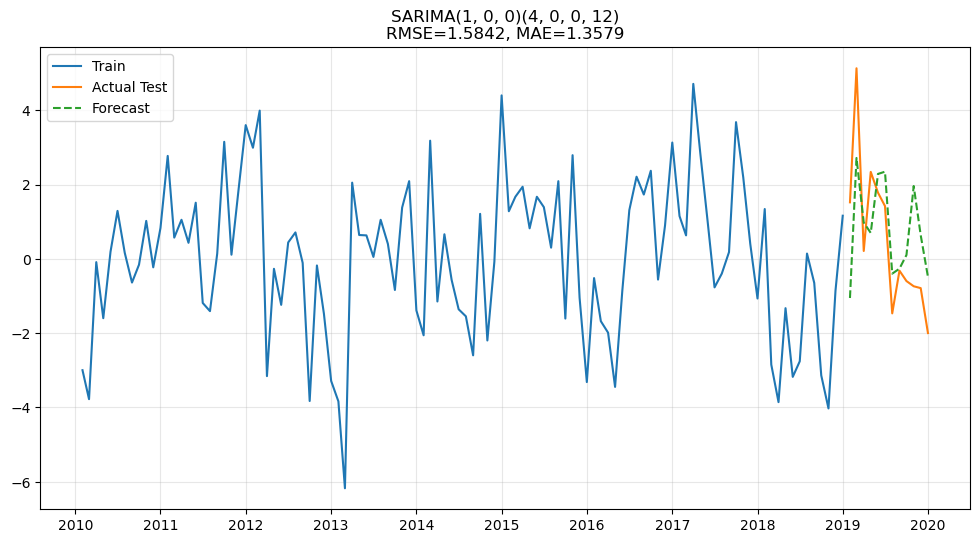

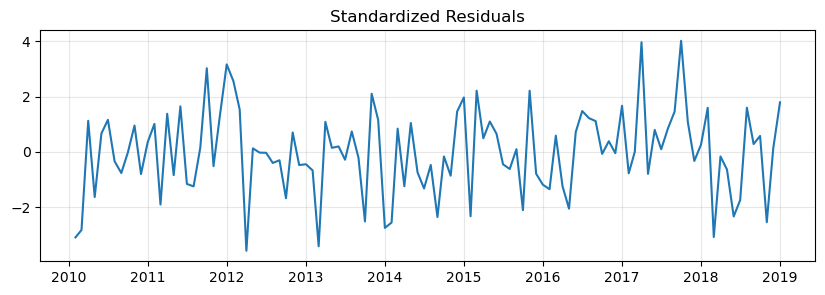

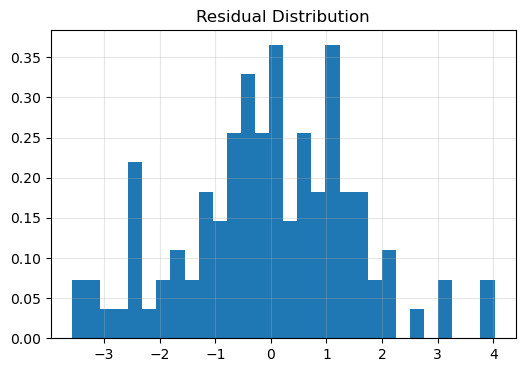

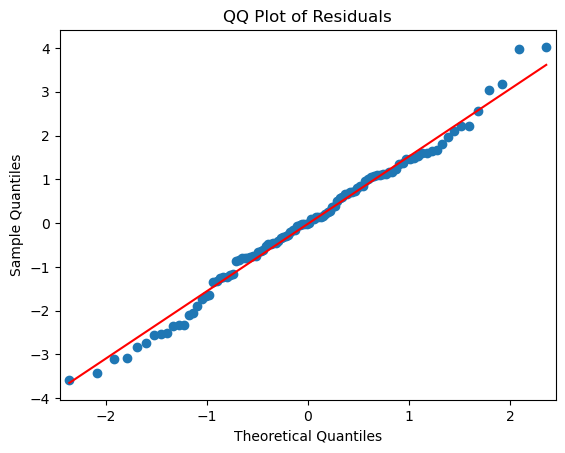

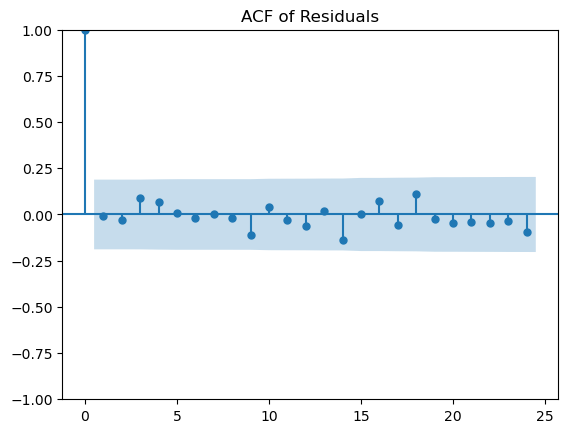

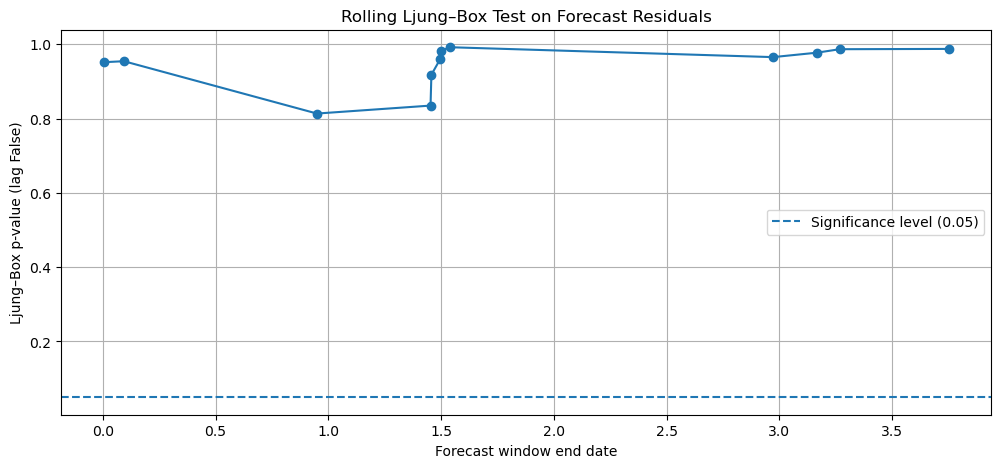

In [42]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [43]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12, exog=exog)

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.00 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,3)[12] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(0,0,0)(0,0,4)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,5)[12] intercept   : AIC=420.388, Time=0.76 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=441.004, Time=0.02 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,0,0)(1,0,3)[12] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(0,0,0)(1,0,4)[12] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.04 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(0,0,0)(2,0,3)[12] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,0,0)(3,0,0)[12] intercept   : AIC=425.607, Ti

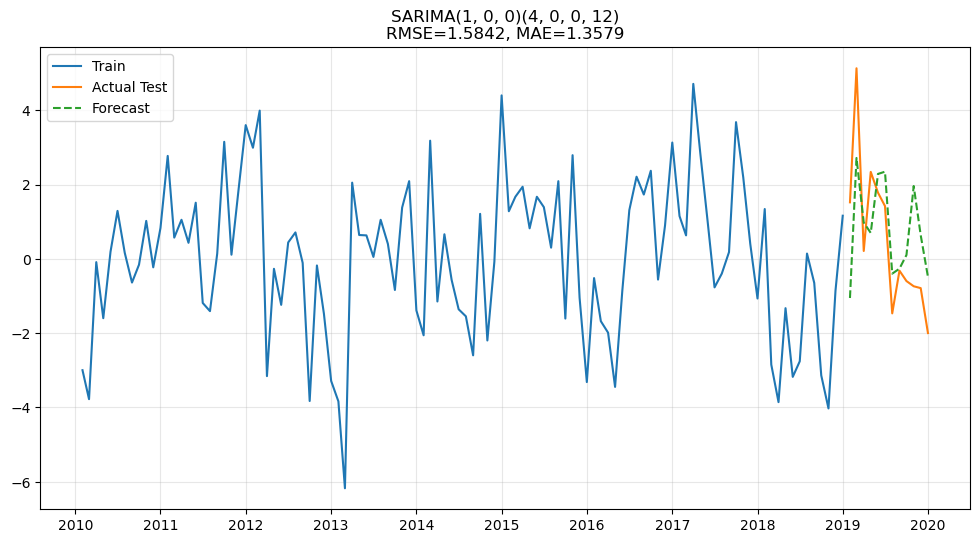

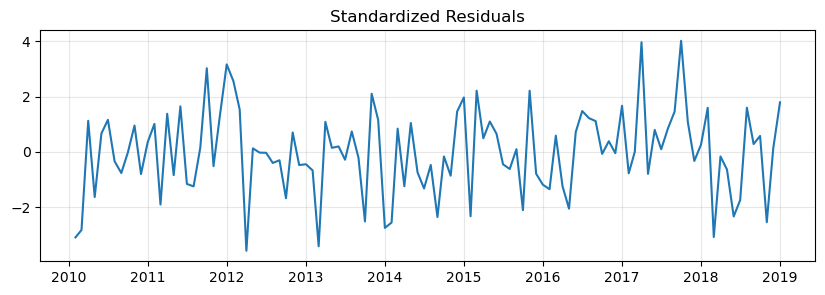

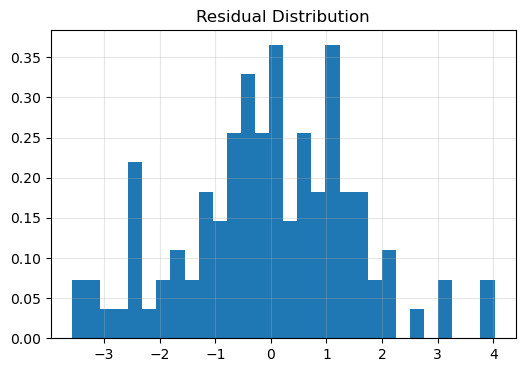

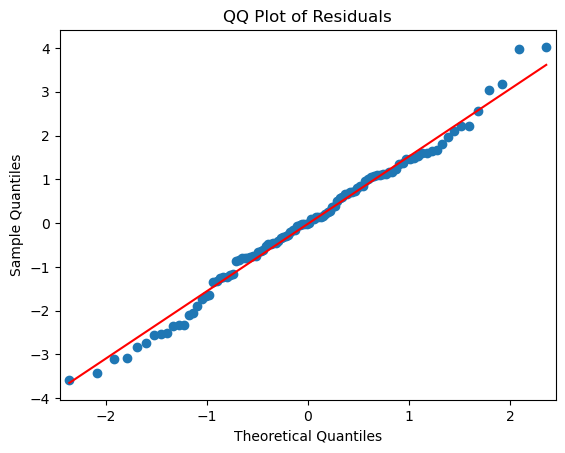

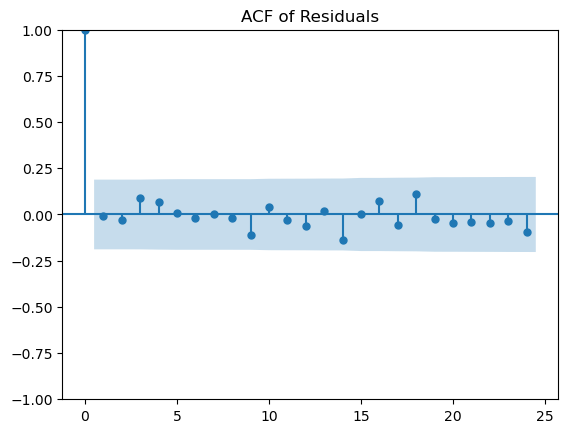

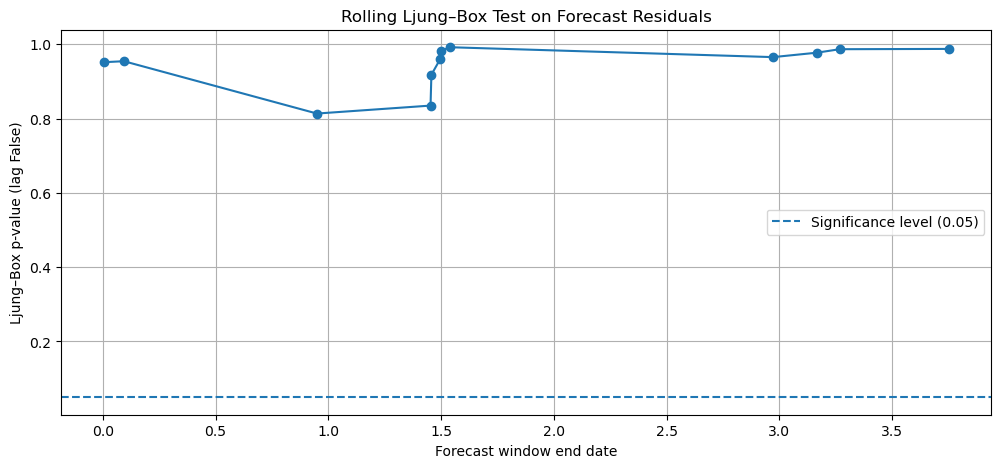

In [44]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [45]:
best_info, scores_df = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=None,
    metric="rmse",
    use="avg",
    verbose=True,
)
cv = best_info["cv_results"]

Data range: 1995-01-01 00:00:00 to 2020-01-01 00:00:00
Training window: 8 years (96 months)
Forecast horizon: 24 months
Testing period: 1996 onwards
Number of CV splits: 8

Split 1/8 - Train: 1996-01 to 2003-12, Test: 2004-01 to 2005-12 - RMSE: 1.4574, MAE: 1.1821
Split 2/8 - Train: 1998-01 to 2005-12, Test: 2006-01 to 2007-12 - RMSE: 1.9517, MAE: 1.5650
Split 3/8 - Train: 2000-01 to 2007-12, Test: 2008-01 to 2009-12 - RMSE: 1.6382, MAE: 1.3121
Split 4/8 - Train: 2002-01 to 2009-12, Test: 2010-01 to 2011-12 - RMSE: 1.5566, MAE: 1.1400
Split 5/8 - Train: 2004-01 to 2011-12, Test: 2012-01 to 2013-12 - RMSE: 2.4498, MAE: 1.8517
Split 6/8 - Train: 2006-01 to 2013-12, Test: 2014-01 to 2015-12 - RMSE: 1.8772, MAE: 1.6258
Split 7/8 - Train: 2008-01 to 2015-12, Test: 2016-01 to 2017-12 - RMSE: 2.1327, MAE: 1.7504
Split 8/8 - Train: 2010-01 to 2017-12, Test: 2018-01 to 2019-12 - RMSE: 2.2100, MAE: 1.7787

OVERALL METRICS (concatenated predictions):
RMSE: 1.9364
MAE: 1.5257

AVERAGE METRICS (acr

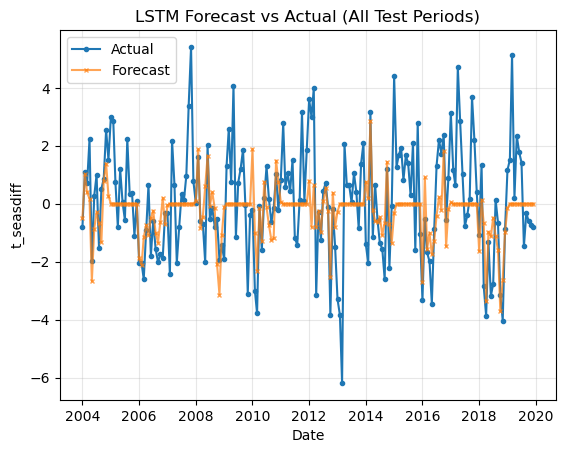

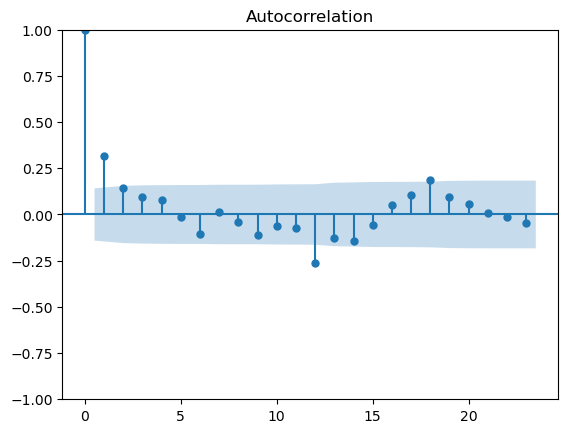

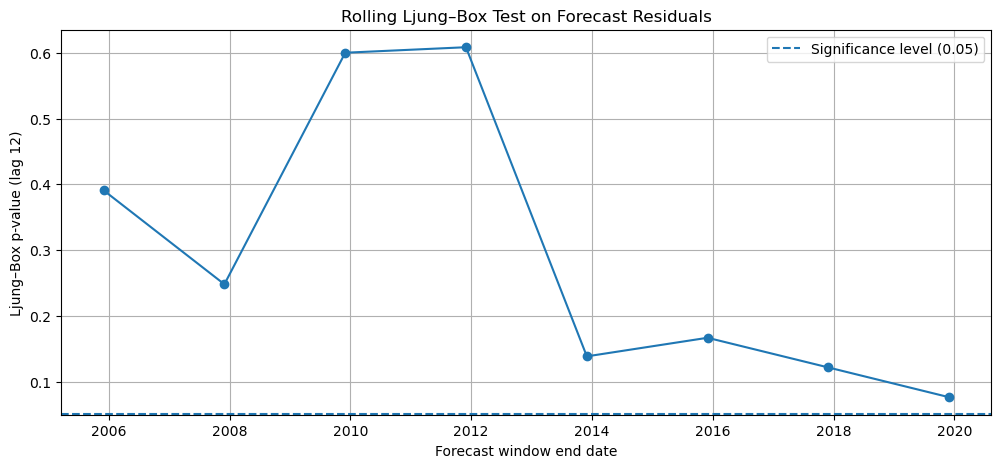

<Figure size 640x480 with 0 Axes>

In [46]:
def _plot_lstm_cv_results(df, target, split_metrics, forecasts, actuals, forecast_months, residuals, lb):
    """Helper function to visualize LSTM cross-validation results."""
    
    forecast_indices = []
    for split_info in split_metrics:
        test_start = split_info['test_start']
        test_end = split_info['test_end']
        indices = df.loc[test_start:test_end].index
        forecast_indices.extend(indices[:forecast_months])
    
    plt.plot(forecast_indices, actuals, label='Actual', marker='o', 
            markersize=3, linewidth=1.5)
    plt.plot(forecast_indices, forecasts, label='Forecast', marker='x', 
            markersize=3, linewidth=1.5, alpha=0.7)
    plt.title('LSTM Forecast vs Actual (All Test Periods)')
    plt.xlabel('Date')
    plt.ylabel(target)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Metrics across splits
    residuals = [a - f for a, f in zip(actuals, forecasts)]
    plot_acf(pd.Series(residuals))

    plot_lb_test(lb)
    plt.tight_layout()
    plt.show()

_plot_lstm_cv_results(
    df=data,
    target=target,
    split_metrics=cv.get("split_metrics", []),  
    forecasts=cv.get("forecasts", []),
    actuals=cv.get("actuals", []),
    forecast_months=24,
    residuals=cv.get("residuals", []),
    lb=pd.DataFrame(cv.get("lb_results", [])),
)

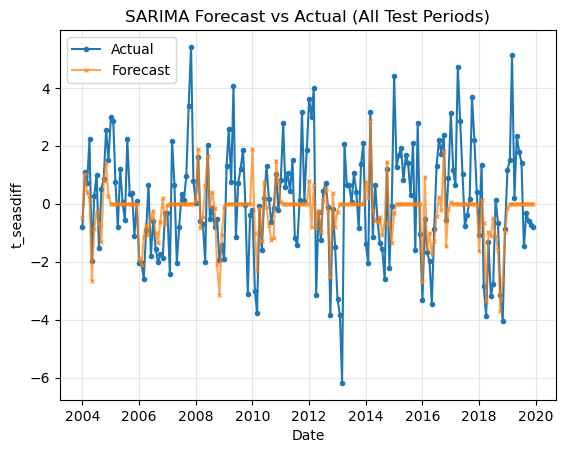

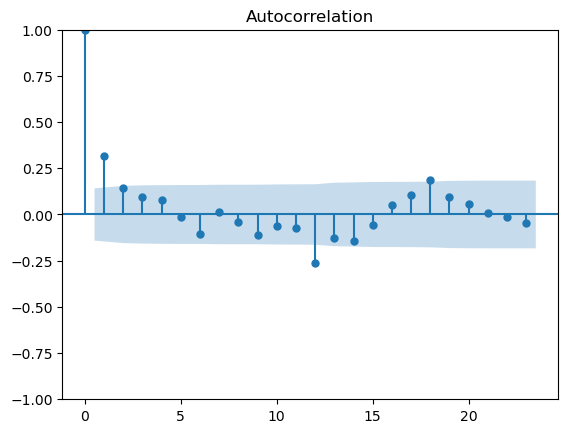

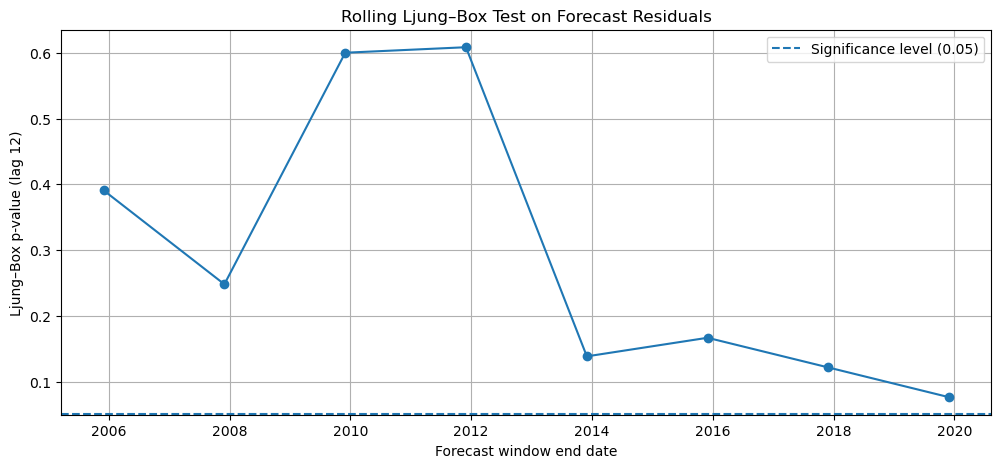

<Figure size 640x480 with 0 Axes>

In [47]:
plot_sarima_cv_results(
    df=data,
    target=target,
    split_metrics=cv.get("split_metrics", []),  
    forecasts=cv.get("forecasts", []),
    actuals=cv.get("actuals", []),
    forecast_months=24,
    residuals=cv.get("residuals", []),
    lb=pd.DataFrame(cv.get("lb_results", [])),
)

In [48]:
last_fold= cv["folds"][-1]
print(last_fold["y_pred"].index)
print(last_fold["y_true"].index)
print(np.var(last_fold["y_pred"]))
print(np.var(last_fold["y_true"]))

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01',
               '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01',
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01'],
              dtype='datetime64[ns]', name='date', freq=None)
DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01',
               '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01',
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01'],
              dtype='datetime64[ns]', name='date', freq=None)
1.1841856867720175
4.6

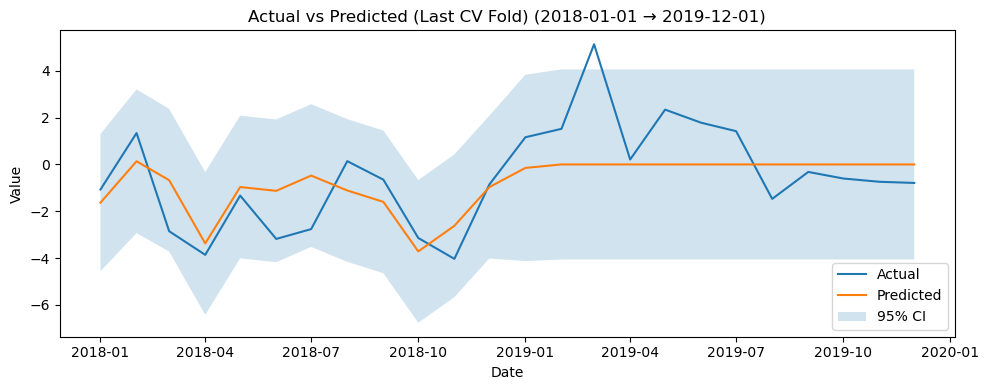

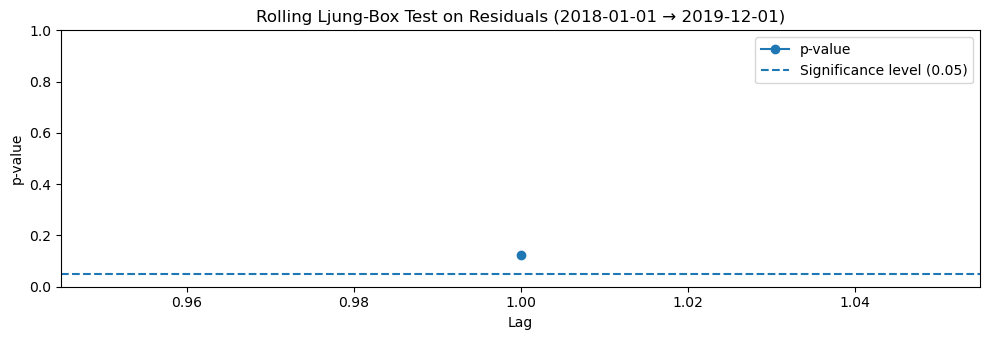

<Figure size 1000x350 with 0 Axes>

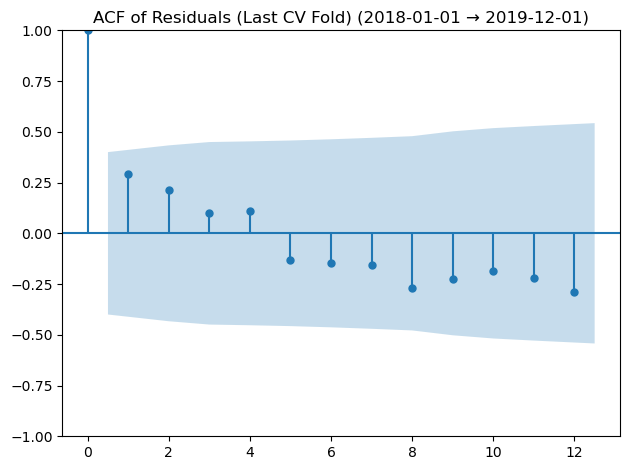

In [49]:
plot_last_fold(last_fold, acf_lags=12, lb_lags=1)

In [50]:
best_info, scores_df = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    train_years=8,
    forecast_months=24,
    test_start_year=1995,
    exog=exog,
    metric="rmse",
    use="avg",
    verbose=True,
)
cv = best_info["cv_results"]

Data range: 1995-01-01 00:00:00 to 2020-01-01 00:00:00
Training window: 8 years (96 months)
Forecast horizon: 24 months
Testing period: 1995 onwards
Number of CV splits: 8

Split 1 failed: NaNs in exog within fold window.
Split 2/8 - Train: 1997-01 to 2004-12, Test: 2005-01 to 2006-12 - RMSE: 1.6244, MAE: 1.3253
Split 3/8 - Train: 1999-01 to 2006-12, Test: 2007-01 to 2008-12 - RMSE: 1.8375, MAE: 1.3975
Split 4/8 - Train: 2001-01 to 2008-12, Test: 2009-01 to 2010-12 - RMSE: 1.8067, MAE: 1.3680
Split 5/8 - Train: 2003-01 to 2010-12, Test: 2011-01 to 2012-12 - RMSE: 1.8926, MAE: 1.4822
Split 6/8 - Train: 2005-01 to 2012-12, Test: 2013-01 to 2014-12 - RMSE: 2.2555, MAE: 1.7180
Split 7/8 - Train: 2007-01 to 2014-12, Test: 2015-01 to 2016-12 - RMSE: 1.9559, MAE: 1.7283
Split 8/8 - Train: 2009-01 to 2016-12, Test: 2017-01 to 2018-12 - RMSE: 2.4829, MAE: 1.9487

OVERALL METRICS (concatenated predictions):
RMSE: 1.9978
MAE: 1.5669

AVERAGE METRICS (across splits):
Average RMSE: 1.9793
Average M

KeyboardInterrupt: 

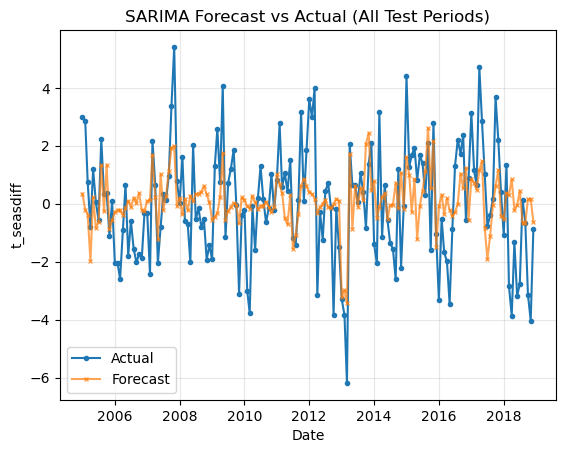

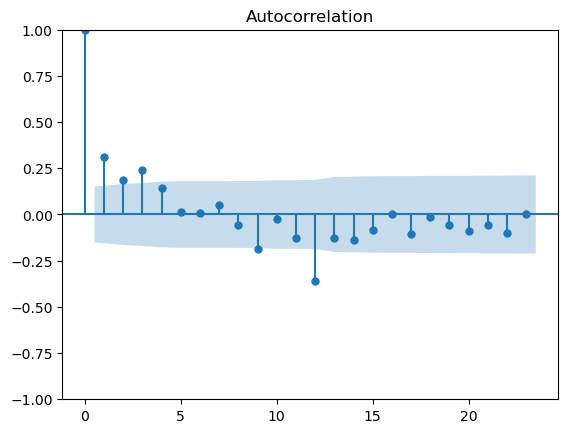

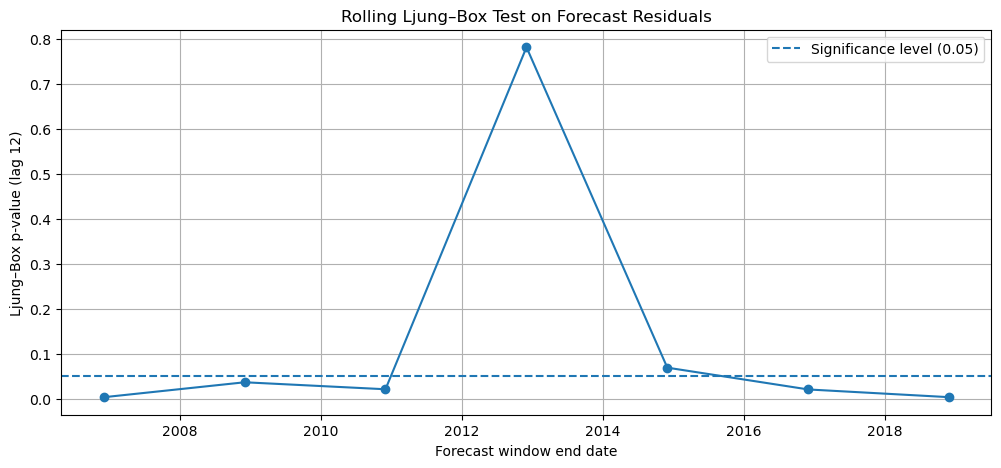

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_sarima_cv_results(
    df=data,
    target=target,
    split_metrics=cv.get("split_metrics", []),  
    forecasts=cv.get("forecasts", []),
    actuals=cv.get("actuals", []),
    forecast_months=24,
    residuals=cv.get("residuals", []),
    lb=pd.DataFrame(cv.get("lb_results", [])),
)

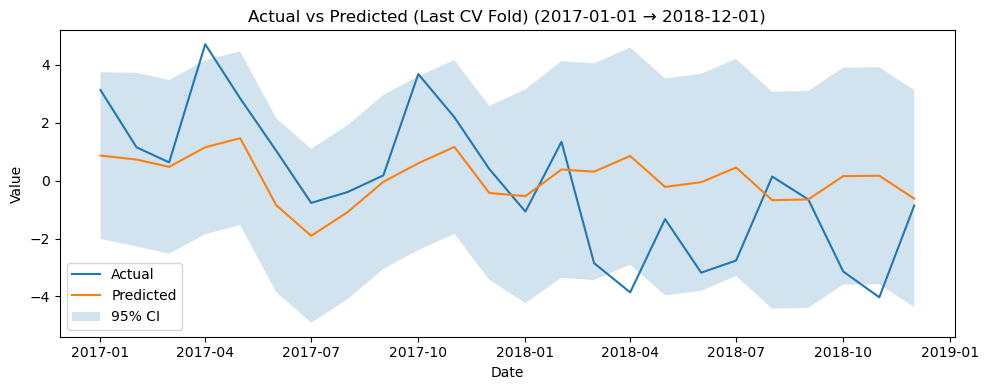

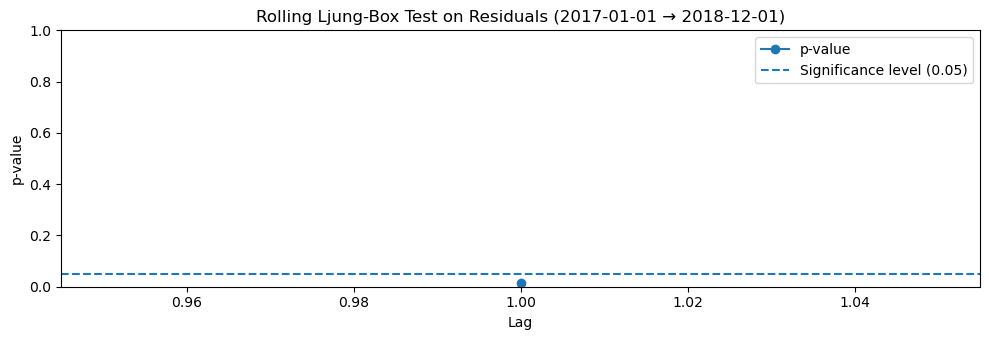

<Figure size 1000x350 with 0 Axes>

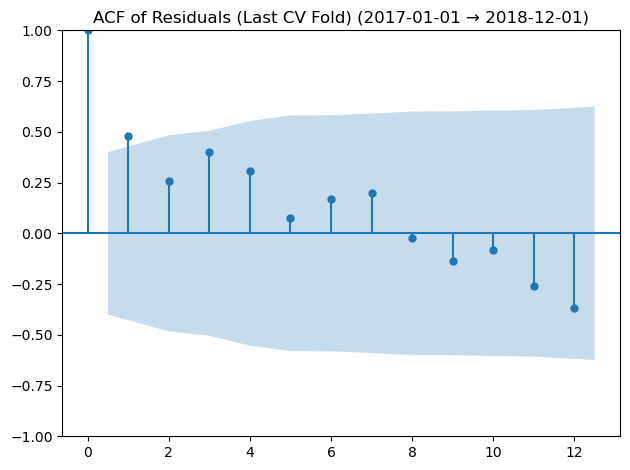

In [ ]:
last_fold= cv["folds"][-1]
plot_last_fold(last_fold, acf_lags=12, lb_lags=1)

# LSTMs

In [ ]:
res = lstm_grid_search_cv(data, 'tdiff', train_years=8, forecast_months=24, test_start_year=1996, epochs=60, verbose=0, param_grid={
    'exog': [['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmed', 'lagged_prec'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax']],
    'lr': [0.001],
    'hidden_size': [50, 25, 100],
    'num_layers': [1, 2],
    'dropout': [0.1, 0.2, 0.3]
    
})

In [ ]:
print_grid_search_results(res['results'], res['best_overall_score'], res['best_overall_results'], res['best_overall_params'],res['best_avg_score'], res['best_avg_results'], res['best_avg_params'],res['best_last_fold_score'], res['best_last_fold_results'], res['best_last_fold_params'])


GRID SEARCH COMPLETE

BEST MODEL BY OVERALL RMSE (concatenated predictions)
Overall RMSE: inf


TypeError: 'NoneType' object is not subscriptable

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_24', 'lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_1', 'lagged_tmin_1', 'lagged_prec_1', 'lagged_tmax_1', 'lagged_tdiff_1', 'lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12' ], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax', 'lagged_tdiff'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)

# Prophet

Prophet is an open-source forecasting model developed by Facebook (Meta) designed specifically for time series forecasting. It focuses on providing accurate forecasts with minimal manual tuning and is well-suited for business-related time series such as sales, demand, traffic, and activity metrics.

In [ ]:
def evaluate(y_test, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tdiff']
})

data.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True)

data

In [ ]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

print(len(test))
print(train.dtypes)
y_test

## Hyperparameter Tuning
In this section, we tune Prophet’s hyperparameters to identify the parameter combination that yields the best performance for our dataset. To achieve this, we use Prophet’s built-in diagnostic tools, **cross_validation** and **performance_metrics**.

The hyperparameters that we tune are:

* **changepoint_prior_scale**: This is probably the most impactful parameter. It determines the flexibility of the trend, and in particular how much the trend changes at the trend changepoints. If it is too small, the trend will be underfit and variance that should have been modeled with trend changes will instead end up being handled with the noise term. If it is too large, the trend will overfit and in the most extreme case the trend will capture yearly seasonality;

* **seasonality_prior_scale**: This parameter controls the flexibility of the seasonality. Similarly, a large value allows the seasonality to fit large fluctuations, a small value shrinks the magnitude of the seasonality;

* **seasonality_mode**: This parameters determines if the model should model an additive or multiplicative seasonality. Options are "additive" or "multiplicative";

In [ ]:
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation
import itertools
from prophet import Prophet

# Define the parameter grid
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    "seasonality_mode": ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(data)  # Fit model with given params
    df_cv = cross_validation(m, initial="7304 days", horizon='1826 days', period= "30 days", parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = tuning_results.sort_values(by='rmse').iloc[0].to_dict()
print(best_params)


In [ ]:
# Fit the model with the best parameters
model = Prophet(changepoint_prior_scale=best_params['changepoint_prior_scale'],
                seasonality_prior_scale=best_params['seasonality_prior_scale'],
                seasonality_mode=best_params['seasonality_mode'])
model.fit(train)
future = model.make_future_dataframe(periods=len(test), freq='MS')

forecast = model.predict(future)

# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
evaluate(y_test, forecast['yhat'][-len(test):])

## Modelling with Rolling window
In this section, we take the hyperparameters obtained from the previous step and apply them to a rolling-window forecasting setup. Our rolling window uses a training period of 8 years followed by a 2-year forecasting horizon.

In [ ]:
window_size = 96  # 8 years
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []

lb_results = []
rmse_per_fold = []

for start in range(0, len(data) - window_size - forecast_horizon + 1, forecast_horizon):

    # Training and test windows
    train_window = data.iloc[start:start + window_size]
    test_window = data.iloc[start + window_size:start + window_size + forecast_horizon]

    # Initialize Prophet model with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )

    # Fit model
    model.fit(train_window)

    # Forecast one full horizon
    future = model.make_future_dataframe(periods=forecast_horizon, freq='MS')
    forecast = model.predict(future)

    # Extract forecast matching the test-window dates
    forecast_window = (
        forecast.set_index('ds')
                .loc[test_window['ds'].values]  # aligned on timestamp
    )

    # Store values
    preds.extend(forecast_window['yhat'].values)
    actuals.extend(test_window['y'].values)
    dates.extend(test_window['ds'].values)

    # Residuals for this window
    residuals = test_window['y'].values - forecast_window['yhat'].values

    # Ljung–Box at seasonal lag
    lb = acorr_ljungbox(
        residuals,
        lags=[12],
        return_df=True
    )

    lb_results.append({
        'ds': test_window['ds'].iloc[-1],   # end of forecast window
        'lb_stat': lb['lb_stat'].iloc[0],
        'p_value': lb['lb_pvalue'].iloc[0]
    })
    rmse = np.sqrt(mean_squared_error(test_window['y'].values, forecast_window['yhat'].values))
    rmse_per_fold.append(rmse)

rmse_mean = np.mean(rmse_per_fold)
rmse_std = np.std(rmse_per_fold, ddof=1)  # sample std

print(f"Mean RMSE: {rmse_mean:.3f}")
print(f"Std. Dev. RMSE: {rmse_std:.3f}")

#DataFrame for plotting
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})
evaluate(actuals, preds)

NameError: name 'Prophet' is not defined

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df["ds"], results_df["actual"], label="Actual", linewidth=2)
plt.plot(results_df["ds"], results_df["predicted"], label="Predicted w/ Prophet (Rolling Forecast)", linewidth=2)
plt.title("Actual vs Predicted values (Rolling Forecast)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
residuals_r = np.array(actuals) - np.array(preds)

plt.figure(figsize=(12, 4))
plt.scatter(results_df["ds"], residuals_r)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

In [ ]:
lb_df = pd.DataFrame(lb_results)

plot_lb_test(lb_df, rolling_window=True)

## ACF computation and diagnosis
In this section we compute the ACF of the residuals to diagnose if the model is working well or not. First we used the regular model with no rolling window to then compare to our rolling window residuals.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Initialize Prophet model with best params
model = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)
model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
df_cv['residual'] = df_cv['y'] - df_cv['yhat']
residuals = df_cv['residual']

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

plot_acf(residuals, lags=24, ax=axes)
axes.set_title("ACF of Residuals")

plt.tight_layout()
plt.show()

Given the plot of the ACF, we can surmise these things:
* Most autocorrelation values lie within the confidence bounds;
* Most autocorrelation values fluctuate around zero;
* There are clear significant spikes at lags 12, 24, etc... for the ACF.

Based on the above, we conclude that the model successfully captures the overall trend and that there is no strong short-term autoregressive structure remaining in the residuals. However, the model does not fully capture the annual seasonal patterns, despite yearly seasonality being explicitly enabled. This behavior is likely due to the dataset showing cyclostationarity at lag 12.

Since Prophet is specifically designed to model seasonal effects directly, we avoid applying seasonal differencing at lag 12. Altering the dataset is not recommended for Prophet, as it would remove seasonal information that the model relies on for forecasting. Instead, we try to solve this issue by adjusting the model’s seasonal parameters to better capture the underlying annual cycle.


In [ ]:
model = Prophet(
    yearly_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)

model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=35  # increase flexibility
)

model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
residuals = df_cv['y'] - df_cv['yhat']

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

plot_acf(residuals, lags=24, ax=axes)
axes.set_title("ACF of Residuals") 

plt.tight_layout()
plt.show()

Increasing the Fourier order of the yearly seasonal component does not eliminate the residual autocorrelation at lag 12. This indicates the presence of time-varying annual seasonality (cyclostationarity), which cannot be fully captured by Prophet’s global seasonal formulation (Prophet assumes seasonality is globally consistent overtime). Nevertheless, the model adequately captures the overall trend and short-term dynamics, and the rolling-window forecasting strategy helps mitigate the impact of this remaining seasonal structure.

In [ ]:
# Using rolling forecast residuals
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

plot_acf(residuals_r, lags=24, ax=axes)
axes.set_title("ACF of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
# Using most recent rolling forecast residuals
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

plot_acf(residuals_r[-forecast_horizon:], lags=23, ax=axes)
axes.set_title("ACF of Residuals")

plt.tight_layout()
plt.show()

# Traditional Machine Learning 

In this section, we attempted to use ML models to predict 'tdiff'. Contrarily to the other sections, we explored calculating tdiff by subtracting the predictions between tmin and tmax. 

Additionally, due to the nature of the models, the predictions had to be made iteratively, having its features changed for every predicted month according to the previous prediction. This means that if we wanted to predict for February of 2019, we would need to take into account the predicted values of January of the same year.

Details and discussion about the results will be presented in the report.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

window_size = 96  # 8 years
forecast_horizon = 24  # 2-year ahead

In [ ]:
"""
This function performs iterative forecasting
The feature description is described in the cell below
"""
def recursive_forecast(model, data, n_steps=12, n_lags=12):
    last_data = data.copy()
    forecast = []
    
    for i in range(n_steps):
        lags = [last_data['y'].iloc[-lag] for lag in range(1, n_lags + 1)]
        
        rolling_3 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(4, len(last_data)+1))])
        rolling_6 = np.mean([last_data['y'].iloc[-j] for j in range(1, min(7, len(last_data)+1))])
        
        next_month = last_data.index[-1] + pd.DateOffset(months=1)
        month_sin = np.sin(2 * np.pi * next_month.month / 12)
        month_cos = np.cos(2 * np.pi * next_month.month / 12)
        
        X_next = np.array(lags + [rolling_3, rolling_6, next_month.month, month_sin, month_cos]).reshape(1, -1)
        
        y_next = model.predict(X_next)[0]
        forecast.append(y_next)
        
        last_data = pd.concat([last_data, pd.DataFrame({'y': [y_next]}, index=[next_month])])
    
    forecast_index = pd.date_range(start=last_data.index[-n_steps], periods=n_steps, freq='MS')
    return pd.Series(forecast, index=forecast_index)

def get_model_prediction(model, train, steps):
    X_train = train.drop(columns=['y'])
    y_train = train['y']

    model.fit(X_train, y_train)
    return recursive_forecast(model, train, n_steps=steps)

In [ ]:
"""
This function prepares the data creating the following features:
- lag_1 to lag_12: previous 12 months of the target variable
- rolling_3: 3-month rolling mean of the target variable
- rolling_6: 6-month rolling mean of the target variable
- month: month of the year as an integer (1-12)
- month_sin: sine transformation of the month
- month_cos: cosine transformation of the month
"""
global_data = load_data()
def get_data(target):
    loaded_data = global_data
    data = pd.DataFrame({
        'date': loaded_data['date'],
        'y': loaded_data[target]
    })
    
    data.set_index('date', inplace=True)
    
    for lag in range(1, 13):
        data[f'lag_{lag}'] = data['y'].shift(lag)
    
    data['rolling_3'] = data['y'].shift(1).rolling(3).mean()
    data['rolling_6'] = data['y'].shift(1).rolling(6).mean()
    
    data['month'] = data.index.month
    data['month_sin'] = np.sin(2 * np.pi * data['month']/12)
    data['month_cos'] = np.cos(2 * np.pi * data['month']/12)
    
    data.dropna(inplace=True)

    return data

## Random Forest

In [ ]:
"""
This function performs sliding window cross-validation using Random Forest
using given hyperparameters. This was done to facilitate grid search.

Instead of predicting directly tdiff, we predict tmax and tmin separately.
"""
def sliding_window_rf(params):
    preds = []
    actuals = []
    dates = []
    lb_results = []
    rmse_per_fold = []

    max_data = get_data('tmax')
    min_data = get_data('tmin')
    diff_data = get_data('tdiff')

    for start in range(0, len(diff_data) - window_size - forecast_horizon + 1, forecast_horizon):
        max_train_window = max_data.iloc[start:start + window_size]
        min_train_window = min_data.iloc[start:start + window_size]
        diff_test_window = diff_data.iloc[start + window_size:start + window_size + forecast_horizon]
        
        rf_max = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )
        
        rf_min = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )

        max_pred_rf = get_model_prediction(rf_max, max_train_window, forecast_horizon)
        min_pred_rf = get_model_prediction(rf_min, min_train_window, forecast_horizon)
        diff_pred_rf = max_pred_rf - min_pred_rf

        preds.extend(diff_pred_rf.values)
        actuals.extend(diff_test_window['y'].values)
        dates.extend(diff_test_window.index)

        residuals = diff_test_window['y'].values - diff_pred_rf.values
        rmse = np.sqrt(mean_squared_error(diff_test_window['y'].values, diff_pred_rf.values))
        rmse_per_fold.append(rmse)

        lb = acorr_ljungbox(
            residuals,
            lags=[12],
            return_df=True
        )

        lb_results.append({
            'ds': diff_test_window.index[-1], 
            'lb_stat': lb['lb_stat'].iloc[0],
            'p_value': lb['lb_pvalue'].iloc[0]
        })

    rmse_mean = np.mean(rmse_per_fold)
    rmse_std = np.std(rmse_per_fold, ddof=1) 

    results_df = pd.DataFrame({
        'ds': dates,
        'actual': actuals,
        'predicted': preds
    })

    return -rmse_mean, rmse_std, results_df, lb_results

In [ ]:
"""
Grid Search for Random Forest hyperparameters
"""
param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5]
}

best_score = float("-inf")
best_params_rf = None
results = []
results_df = pd.DataFrame()
results_lb = []

keys, values = zip(*param_grid_rf.items())

for combo in itertools.product(*values):
    params = dict(zip(keys, combo))

    score, std, new_results_df, new_results_lb = sliding_window_rf(params)

    results.append((params, score))

    if score > best_score:
        best_score = score
        best_params_rf = params
        results_df = new_results_df
        results_lb = new_results_lb

print(f"Params: {best_params_rf} → Score: {-best_score:.4f}")
plots_from_ml_results(results_df, results_lb)

In [ ]:
"""
Execution with best Random Forest parameters to predict the last two years
"""
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []
lb_results = []

max_data = get_data('tmax')
min_data = get_data('tmin')
diff_data = get_data('tdiff')

train_max = max_data.iloc[:-forecast_horizon]
train_min = min_data.iloc[:-forecast_horizon]
test_diff = diff_data.iloc[-forecast_horizon:]

rf_max = RandomForestRegressor(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)
        

rf_min = RandomForestRegressor(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)
      

max_pred_rf = get_model_prediction(rf_max, train_max, forecast_horizon)
min_pred_rf = get_model_prediction(rf_min, train_min, forecast_horizon)
diff_pred_rf = max_pred_rf - min_pred_rf

preds.extend(diff_pred_rf.values)
actuals.extend(test_diff['y'].values)
dates.extend(test_diff.index)

residuals = test_diff['y'].values - diff_pred_rf.values

lb = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

lb_results.append({
    'ds': test_diff.index[-1],   
    'lb_stat': lb['lb_stat'].iloc[0],
    'p_value': lb['lb_pvalue'].iloc[0]
})

evaluate(actuals, preds)
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})

plots_from_ml_results(results_df, lb_results)

## XGBoost

In [ ]:
"""
This function performs sliding window cross-validation using XGBoost
using given hyperparameters. This was done to facilitate grid search.

Instead of predicting directly tdiff, we predict tmax and tmin separately.
"""
def sliding_window_xgb(params):
    preds = []
    actuals = []
    dates = []
    lb_results = []
    rmse_per_fold = []

    max_data = get_data('tmax')
    min_data = get_data('tmin')
    diff_data = get_data('tdiff')

    for start in range(0, len(diff_data) - window_size - forecast_horizon + 1, forecast_horizon):
        max_train_window = max_data.iloc[start:start + window_size]
        min_train_window = min_data.iloc[start:start + window_size]
        diff_test_window = diff_data.iloc[start + window_size:start + window_size + forecast_horizon]

        
        xgb_max = XGBRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )
        
        xgb_min = XGBRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )

        max_pred_xgb = get_model_prediction(xgb_max, max_train_window, forecast_horizon)
        min_pred_xgb = get_model_prediction(xgb_min, min_train_window, forecast_horizon)
        diff_pred_xgb = max_pred_xgb - min_pred_xgb

        preds.extend(diff_pred_xgb.values)
        actuals.extend(diff_test_window['y'].values)
        dates.extend(diff_test_window.index)

        residuals = diff_test_window['y'].values - diff_pred_xgb.values
        rmse = np.sqrt(mean_squared_error(diff_test_window['y'].values, diff_pred_xgb.values))
        rmse_per_fold.append(rmse)

        lb = acorr_ljungbox(
            residuals,
            lags=[12],
            return_df=True
        )

        lb_results.append({
            'ds': diff_test_window.index[-1],
            'lb_stat': lb['lb_stat'].iloc[0],
            'p_value': lb['lb_pvalue'].iloc[0]
        })

    rmse_mean = np.mean(rmse_per_fold)
    rmse_std = np.std(rmse_per_fold, ddof=1)

    results_df = pd.DataFrame({
        'ds': dates,
        'actual': actuals,
        'predicted': preds
    })

    return -rmse_mean, rmse_std, results_df, lb_results

In [ ]:
"""
Grid Search for XGBoost hyperparameters
"""
param_grid_xgb = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

best_score = float("-inf")
best_params_xgb = None
results = []
results_df = pd.DataFrame()
results_lb = []

keys, values = zip(*param_grid_xgb.items())

for combo in itertools.product(*values):
    params = dict(zip(keys, combo))

    score, std, new_results_df, new_results_lb = sliding_window_xgb(params)

    results.append((params, score))

    if score > best_score:
        best_score = score
        best_params_xgb = params
        results_df = new_results_df
        results_lb = new_results_lb

print(f"Params: {best_params_xgb} → Score: {-best_score:.4f}")
plots_from_ml_results(results_df, results_lb)

In [ ]:
"""
Execution with best XGBoost parameters to predict the last two years
"""
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []
lb_results = []

max_data = get_data('tmax')
min_data = get_data('tmin')
diff_data = get_data('tdiff')

train_max = max_data.iloc[:-forecast_horizon]
train_min = min_data.iloc[:-forecast_horizon]
test_diff = diff_data.iloc[-forecast_horizon:]

xgb_max = XGBRegressor(
    **best_params_xgb,
    random_state=42,
    n_jobs=-1
)

xgb_min = XGBRegressor(
    **best_params_xgb,
    random_state=42,
    n_jobs=-1
)

max_pred_xgb = get_model_prediction(xgb_max, train_max, forecast_horizon)
min_pred_xgb = get_model_prediction(xgb_min, train_min, forecast_horizon)
diff_pred_xgb = max_pred_xgb - min_pred_xgb

preds.extend(diff_pred_xgb.values)
actuals.extend(test_diff['y'].values)
dates.extend(test_diff.index)

residuals = test_diff['y'].values - diff_pred_xgb.values
lb = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

lb_results.append({
    'ds': test_diff.index[-1],  
    'lb_stat': lb['lb_stat'].iloc[0],
    'p_value': lb['lb_pvalue'].iloc[0]
})

evaluate(actuals, preds)
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})

plots_from_ml_results(results_df, lb_results)